# Logistic Regression

In this notebook we test logistic regression for predicting the study suitability rating.
The target is still `rating` from 1 to 5.

## Load data


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# Make imports work from the MAL folder
mal_dir = Path.cwd().parent
if str(mal_dir) not in sys.path:
    sys.path.append(str(mal_dir))

from scripts.preprocessing import AutomatedPreprocessor

DATA_PATH = mal_dir / "data" / "mock" / "new" / "data.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,max30minTemp,min30minTemp,mean30minTemp,trend30minTemp,std30minTemp,max30minHumidity,min30minHumidity,mean30minHumidity,trend30minHumidity,std30minHumidity,...,min30minLight,mean30minLight,trend30minLight,std30minLight,max30minCO2,min30minCO2,mean30minCO2,trend30minCO2,std30minCO2,rating
0,23.718,23.7,23.709000,0.000000,0.012728,26.29,26.272,26.28100,0.000000,0.012728,...,578.400000,581.800000,0.000000,4.808326,760.400000,749.2,754.800000,0.000000,7.919596,5
1,23.730,23.7,23.716000,0.010500,0.015100,26.29,26.230,26.26400,-0.025500,0.030790,...,572.666667,578.755556,-4.566667,6.274227,769.666667,749.2,759.755556,7.433333,10.248541,4
2,23.730,23.7,23.717625,0.005833,0.012750,26.29,26.125,26.22925,-0.046111,0.073907,...,493.750000,557.504167,-23.842593,42.810397,774.750000,749.2,763.504167,6.824074,11.235216,4
3,23.754,23.7,23.724900,0.009328,0.019661,26.29,26.125,26.22340,-0.029344,0.065328,...,488.600000,543.723333,-24.416146,48.208966,779.000000,749.2,766.603333,6.261979,11.945573,4
4,23.760,23.7,23.730750,0.010916,0.022684,26.29,26.125,26.22950,-0.018327,0.060312,...,488.600000,547.880556,-15.849340,44.305513,790.000000,749.2,770.502778,7.309736,14.331482,4


In [2]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 2664
Columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2664 entries, 0 to 2663
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   max30minTemp        2664 non-null   float64
 1   min30minTemp        2664 non-null   float64
 2   mean30minTemp       2664 non-null   float64
 3   trend30minTemp      2664 non-null   float64
 4   std30minTemp        2664 non-null   float64
 5   max30minHumidity    2664 non-null   float64
 6   min30minHumidity    2664 non-null   float64
 7   mean30minHumidity   2664 non-null   float64
 8   trend30minHumidity  2664 non-null   float64
 9   std30minHumidity    2664 non-null   float64
 10  max30minLight       2664 non-null   float64
 11  min30minLight       2664 non-null   float64
 12  mean30minLight      2664 non-null   float64
 13  trend30minLight     2664 non-null   float64
 14  std30minLight       2664 non-null   float64
 15  max30minCO2         2664 non-nul

## Check the target


In [3]:
df["rating"].value_counts().sort_index()

rating
2       8
3    1416
4    1174
5      66
Name: count, dtype: int64

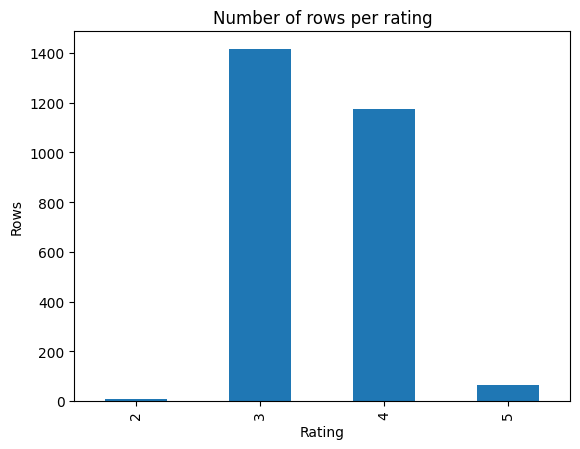

In [4]:
df["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of rows per rating")
plt.xlabel("Rating")
plt.ylabel("Rows")
plt.show()

The ratings are not equally distributed. Most rows are rating 3 and 4.
This means accuracy alone can be misleading, so we also look at F1 score.

## Select features and target


In [5]:
TARGET_COLUMN = "rating"

columns_to_ignore = [
    TARGET_COLUMN,
    "timePeriod",
    "session_id",
    "sent_at",
    "date",
    "Date",
    "id",
]

feature_columns = [
    column for column in df.columns
    if column not in columns_to_ignore
    and pd.api.types.is_numeric_dtype(df[column])
]

X = df[feature_columns].copy()
y = df[TARGET_COLUMN].copy()

print("Features used:")
for column in feature_columns:
    print("-", column)

print(f"\nNumber of features: {len(feature_columns)}")

Features used:
- max30minTemp
- min30minTemp
- mean30minTemp
- trend30minTemp
- std30minTemp
- max30minHumidity
- min30minHumidity
- mean30minHumidity
- trend30minHumidity
- std30minHumidity
- max30minLight
- min30minLight
- mean30minLight
- trend30minLight
- std30minLight
- max30minCO2
- min30minCO2
- mean30minCO2
- trend30minCO2
- std30minCO2

Number of features: 20


## Split data


In [6]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.2,
    random_state=42,
    stratify=y_train_val,
)

print(f"Train rows: {len(X_train)}")
print(f"Validation rows: {len(X_val)}")
print(f"Test rows: {len(X_test)}")

Train rows: 1704
Validation rows: 427
Test rows: 533


## Preprocess data

We use the same preprocessing helper as the other MAL notebooks.

In [7]:
preprocessor = AutomatedPreprocessor()

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.head()

,trend30minTemp,std30minTemp,trend30minLight,std30minCO2,min30minTemp_max30minTemp_mean30minTemp,min30minLight_mean30minLight,max30minCO2_min30minCO2_mean30minCO2_min30minHumidity_max30minHumidity_mean30minHumidity,max30minLight_std30minLight,std30minHumidity_trend30minHumidity_trend30minCO2
0,-0.004853,-0.888296,-0.001193,-0.974371,-0.586617,-0.693142,-0.539502,-0.719362,-0.371168
1,-0.023362,-0.819008,-0.001193,-1.075882,-0.733565,-0.693142,-0.666863,-0.719362,-0.370678
2,0.279782,-0.448589,-0.116465,1.027042,0.645089,1.684411,1.148977,0.513605,-0.057527
3,4.585064,4.976380,1.073299,1.879459,0.442288,1.391634,0.184563,1.623600,0.920247
4,-0.846313,0.279429,-0.208213,0.787402,1.694193,0.950918,1.349203,0.685956,-0.232827


## Baseline model

First we make a simple baseline.
This model always predicts the most common rating.

In [8]:
baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train_processed, y_train)
baseline_predictions = baseline.predict(X_val_processed)

baseline_accuracy = accuracy_score(y_val, baseline_predictions)
baseline_f1 = f1_score(y_val, baseline_predictions, average="macro", zero_division=0)

print(f"Baseline accuracy: {baseline_accuracy:.3f}")
print(f"Baseline macro F1: {baseline_f1:.3f}")

Baseline accuracy: 0.532
Baseline macro F1: 0.174


## Logistic regression

In [9]:
logistic_model = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    class_weight="balanced",
)

logistic_model.fit(X_train_processed, y_train)
logistic_predictions = logistic_model.predict(X_val_processed)

logistic_accuracy = accuracy_score(y_val, logistic_predictions)
logistic_f1 = f1_score(y_val, logistic_predictions, average="macro", zero_division=0)

print(f"Logistic regression accuracy: {logistic_accuracy:.3f}")
print(f"Logistic regression macro F1: {logistic_f1:.3f}")

Logistic regression accuracy: 0.674
Logistic regression macro F1: 0.414


In [10]:
print(classification_report(y_val, logistic_predictions, zero_division=0))

              precision    recall  f1-score   support

           2       0.00      0.00      0.00         1
           3       0.82      0.79      0.80       227
           4       0.81      0.54      0.65       188
           5       0.12      0.64      0.20        11

    accuracy                           0.67       427
   macro avg       0.44      0.49      0.41       427
weighted avg       0.80      0.67      0.72       427



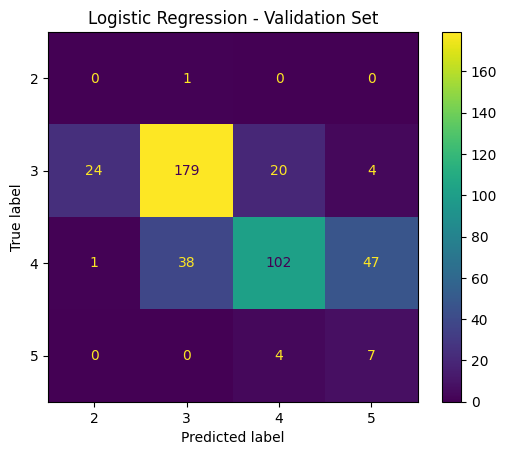

In [11]:
ConfusionMatrixDisplay.from_predictions(y_val, logistic_predictions)

plt.title("Logistic Regression - Validation Set")
plt.show()

## Regularisation

`C` controls how strong the regularisation is.

Small `C` means stronger regularisation.
Large `C` means weaker regularisation.

In [12]:
results = []

for C in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        class_weight="balanced",
        C=C,
    )
    
    model.fit(X_train_processed, y_train)
    predictions = model.predict(X_val_processed)
    
    results.append({
        "C": C,
        "accuracy": accuracy_score(y_val, predictions),
        "macro_f1": f1_score(y_val, predictions, average="macro", zero_division=0),
    })

results_df = pd.DataFrame(results)
results_df

,C,accuracy,macro_f1
0,0.01,0.665105,0.425337
1,0.10,0.665105,0.398679
2,1.00,0.674473,0.414269
3,10.00,0.676815,0.421987
4,100.00,0.672131,0.418587


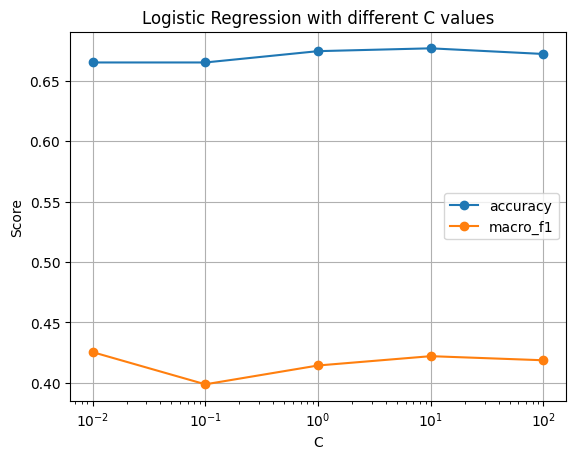

In [13]:
results_df.plot(x="C", y=["accuracy", "macro_f1"], marker="o")

plt.xscale("log")
plt.title("Logistic Regression with different C values")
plt.xlabel("C")
plt.ylabel("Score")
plt.grid(True)
plt.show()

## Final test

Now we use the best `C` from the validation results and test it on unseen test data.

In [14]:
best_C = results_df.sort_values("macro_f1", ascending=False).iloc[0]["C"]

final_model = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    class_weight="balanced",
    C=best_C,
)

final_model.fit(X_train_processed, y_train)
test_predictions = final_model.predict(X_test_processed)

test_accuracy = accuracy_score(y_test, test_predictions)
test_f1 = f1_score(y_test, test_predictions, average="macro", zero_division=0)

print(f"Best C: {best_C}")
print(f"Test accuracy: {test_accuracy:.3f}")
print(f"Test macro F1: {test_f1:.3f}")

Best C: 0.01
Test accuracy: 0.664
Test macro F1: 0.410


In [15]:
print(classification_report(y_test, test_predictions, zero_division=0))

              precision    recall  f1-score   support

           2       0.04      0.50      0.07         2
           3       0.78      0.84      0.81       283
           4       0.80      0.46      0.59       235
           5       0.10      0.54      0.17        13

    accuracy                           0.66       533
   macro avg       0.43      0.58      0.41       533
weighted avg       0.77      0.66      0.69       533



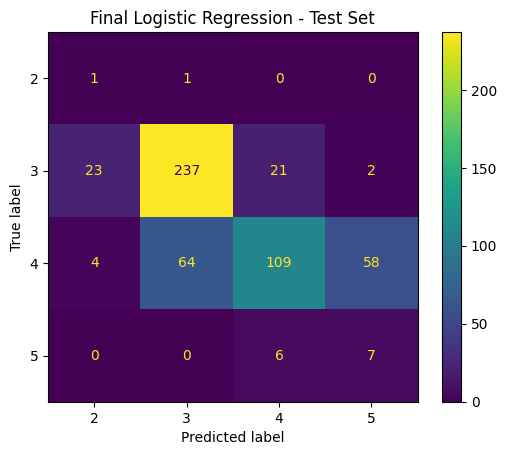

In [16]:
ConfusionMatrixDisplay.from_predictions(y_test, test_predictions)

plt.title("Final Logistic Regression - Test Set")
plt.show()

## Conclusion

Logistic regression was tested as a simple classification model for predicting the rating.
The baseline model had accuracy 0.532 and macro F1 0.174.
The final logistic regression model had test accuracy 0.664 and macro F1 0.410.

This means logistic regression performs better than the baseline.
The dataset is not balanced. Most rows have rating 3 or 4, there are only a few rows with rating 2 and 5, and there are no rows with rating 1. Because of this, the model is much better at predicting rating 3 and 4 than the rare ratings.
Compared with Random Forest, logistic regression has lower accuracy, but it is still useful because it is simpler and easier to explain.

The final model should probably not be logistic regression, but this experiment is useful as a baseline.
